In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import scarf

scarf.configure_output(level="ERROR", progress=False)
repository = scarf.cytebase.connect("scarf_docs")
mount_directory = TemporaryDirectory()
staged_dataset = repository.download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination=mount_directory.name,
    zarr=True,
)
source_path = staged_dataset / 'data.zarr'
target_path = Path(mount_directory.name) / 'analysis.zarr'

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

In [2]:
mounted = scarf.mount_datastore(
    str(source_path),
    at=str(target_path),
    default_assay='RNA',
    nthreads=4,
)

In [3]:
mounted_run = mounted.pipeline.run(label="mounted_analysis")

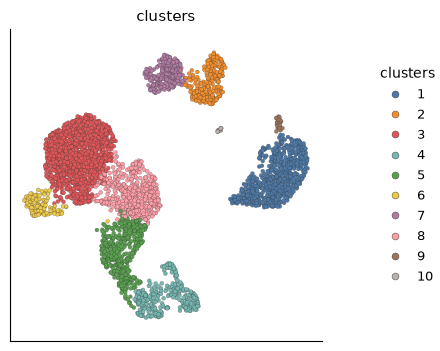

In [4]:
mounted.plots.embedding(run=mounted_run, color_by="clusters")

In [5]:
reopened = scarf.DataStore(
    str(target_path),
    nthreads=4,
)
reopened_run = reopened.pipeline.open(run_id=mounted_run.run_id)
reopened_run.status

'completed'